=== Decision Tree ===
Accuracy: 0.46984924623115576
ROC-AUC: 0.4687243431855501
              precision    recall  f1-score   support

           0       0.41      0.46      0.43       174
           1       0.53      0.48      0.50       224

    accuracy                           0.47       398
   macro avg       0.47      0.47      0.47       398
weighted avg       0.48      0.47      0.47       398


=== Random Forest ===
Accuracy: 0.5050251256281407
ROC-AUC: 0.49997434318555006
              precision    recall  f1-score   support

           0       0.44      0.46      0.45       174
           1       0.56      0.54      0.55       224

    accuracy                           0.51       398
   macro avg       0.50      0.50      0.50       398
weighted avg       0.51      0.51      0.51       398


Feature Importance:
           Feature  Importance
3            SP500    0.267189
0        sentiment    0.266402
1  headline_length    0.250929
2       word_count    0.215480


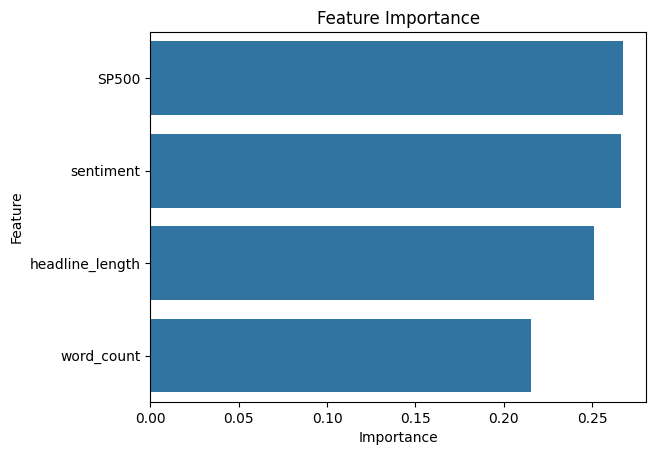

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# ======================
# 1. LOAD DATA
# ======================
df = pd.read_csv("final_dataset.csv")

# ======================
# 2. FEATURES & LABEL
# ======================
features = ["sentiment", "headline_length", "word_count", "SP500"]
X = df[features]
y = df["Label"]

# ======================
# 3. TRAIN-TEST SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# 4. DECISION TREE
# ======================
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()